## Imports

In [1]:
import pandas as pd
import os

from pathlib import Path
from datetime import datetime
from anonymeter.evaluators import SinglingOutEvaluator
from matplotlib import pyplot as plt
import time

import seaborn as sns
from collections import defaultdict

In [2]:
max_attempts = 1_000_000
n_iters = 5
n_cols_to_try = [3, 12] # for the multivariate attack

## Evaluate CTGAN data

### Read data

In [3]:
dataset_dir = "./datasets/"

ori = pd.read_csv(os.path.join(dataset_dir, "adults_train.csv"))
syn = pd.read_csv(os.path.join(dataset_dir, "adults_syn_ctgan.csv"))
control = pd.read_csv(os.path.join(dataset_dir, "adults_control.csv"))

### Univariate attack

In [4]:
risks = defaultdict(list)
start_time = time.time()
for i in range(n_iters):
    evaluator = SinglingOutEvaluator(
        ori=ori, syn=syn, control=control, n_attacks=500
    )

    evaluator.evaluate(mode="univariate")
    risk = evaluator.risk()
    risks[1].append(risk)
print(f"Average time: {(time.time() - start_time) / n_iters:.2f} seconds")

Average time: 61.42 seconds


### Multivariate attacks

In [5]:
for n in n_cols_to_try:
    start_time = time.time()
    for i in range(n_iters):
        evaluator = SinglingOutEvaluator(
            ori=ori,
            syn=syn,
            control=control,
            n_attacks=500,
            n_cols=n,
            max_attempts=max_attempts,
        )

        evaluator.evaluate(mode="multivariate")
        risk = evaluator.risk()
        risks[n].append(risk)
    print(f"Average time: {(time.time() - start_time) / n_iters:.2f} seconds")

Average time: 916.46 seconds
Average time: 173.45 seconds


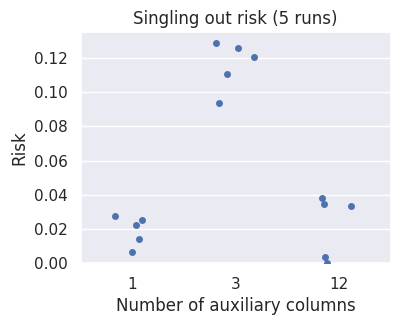

In [6]:
df = pd.DataFrame(
    [(k, r.value) for k, lst in risks.items() for r in lst],
    columns=["aux_cols", "risk"]
)

sns.set(style="darkgrid")
plt.figure(figsize=(4, 3))
ax = sns.stripplot(data=df, x="aux_cols", y="risk", jitter=0.2)
ax.set_xlabel("Number of auxiliary columns")
ax.set_ylabel("Risk")
plt.ylim(bottom=0.0)
plt.title(f"Singling out risk ({n_iters} runs)")
plt.show()

## Evaluate artificial data

### Prepare artificial data

In [7]:
adult_combined = pd.concat([ori, control], axis=0)

In [8]:
def split_train_control_release():
    # Random shuffle and split
    df = adult_combined.sample(frac=1, random_state=42)

    if len(df) % 3 != 0:
        df = df[: -(len(df) % 3)]

    df_train = df[: len(df) // 3]
    df_control = df[len(df) // 3 : 2 * len(df) // 3]
    df_release = df[2 * len(df) // 3 :]

    return df_train, df_release, df_control

In [9]:
df_train, df_release, df_control = split_train_control_release()

### Leaky synthesis

In [10]:
def synthesize_leaky(
    df_train: pd.DataFrame, df_release: pd.DataFrame, leak_fraction: float
) -> pd.DataFrame:
    """
    Generate a synthetic dataset that contains a fraction of training data and release data.
    Assumes df_train and df_release have the same size and samples without replacement.

    Parameters:
    -----------
    df_train : pandas.DataFrame
        Original training dataset to leak from
    df_release : pandas.DataFrame
        Release dataset to sample from
    leak_fraction : float
        Fraction of training data to include (between 0 and 1)

    Returns:
    --------
    pandas.DataFrame
        Synthetic dataset containing leaked training data and release data samples
    """

    # Validate inputs
    if not 0 <= leak_fraction <= 1:
        raise ValueError("leak_fraction must be between 0 and 1")

    # Calculate number of samples to take from each dataset
    n_samples = len(df_train)
    n_leak = int(n_samples * leak_fraction)
    n_release = n_samples - n_leak

    # Randomly sample from training data
    leaked_samples = df_train.sample(n=n_leak, replace=False)

    # Randomly sample from release data without replacement
    release_samples = df_release.sample(n=n_release, replace=False)

    # Combine the samples
    X_leaky_syn = pd.concat([leaked_samples, release_samples])

    # Shuffle the combined dataset
    X_leaky_syn = X_leaky_syn.sample(frac=1).reset_index(drop=True)

    return X_leaky_syn

In [11]:
leak_fraction = 0.2
df_syn = synthesize_leaky(df_train, df_release, leak_fraction=leak_fraction)

### Univariate attack

In [12]:
risks_leaky = defaultdict(list)
start_time = time.time()
for i in range(n_iters):
    evaluator = SinglingOutEvaluator(
        ori=df_train, syn=df_syn, control=df_control, n_attacks=500
    )

    evaluator.evaluate(mode="univariate")
    risk = evaluator.risk()
    risks_leaky[1].append(risk)
print(f"Average time: {(time.time() - start_time) / n_iters:.2f} seconds")

Average time: 5.12 seconds


### Multivariate attacks

In [13]:
for n in n_cols_to_try:
    start_time = time.time()
    for i in range(n_iters):
        evaluator = SinglingOutEvaluator(
            ori=df_train,
            syn=df_syn,
            control=df_control,
            n_attacks=500,
            n_cols=n,
            max_attempts=max_attempts,
        )

        evaluator.evaluate(mode="multivariate")
        risk = evaluator.risk()
        risks_leaky[n].append(risk)
    print(f"Average time: {(time.time() - start_time) / n_iters:.2f} seconds")

Average time: 394.08 seconds
Average time: 20.06 seconds


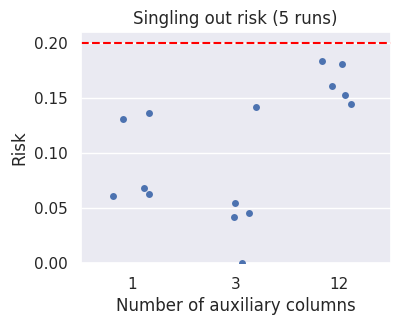

In [14]:
df = pd.DataFrame(
    [(k, r.value) for k, lst in risks_leaky.items() for r in lst],
    columns=["aux_cols", "risk"]
)

plt.figure(figsize=(4, 3))
ax = sns.stripplot(data=df, x="aux_cols", y="risk", jitter=0.2)
ax.set_xlabel("Number of auxiliary columns")
ax.set_ylabel("Risk")
plt.axhline(y=leak_fraction, color='red', linestyle='--')
plt.ylim(bottom=0.0)
plt.title(f"Singling out risk ({n_iters} runs)")
plt.show()